In [3]:
# Импорт необходимых библиотек
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import random
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [4]:
# Загрузка датасета YouTube
print("Загрузка данных YouTube...")
file_path = "com-youtube.ungraph.txt"

# Пропускаем первые 4 строки с комментариями
edges = []
node_set = set()
edge_count = 0

with open(file_path, 'r') as f:
    for i, line in enumerate(f):
        if i < 4:  # Пропускаем заголовки
            continue
        parts = line.strip().split()
        if len(parts) == 2:
            from_node, to_node = int(parts[0]), int(parts[1])
            edges.append((from_node, to_node))
            node_set.add(from_node)
            node_set.add(to_node)
            edge_count += 1

print(f"Загружено: {len(edges)} ребер, {len(node_set)} уникальных узлов")
print("Первые 10 ребер:", edges[:10])

Загрузка данных YouTube...
Загружено: 2987624 ребер, 1134890 уникальных узлов
Первые 10 ребер: [(1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (1, 10), (1, 11)]



Создание графа...
Количество узлов: 1134890
Количество ребер: 2987624
Средняя степень: 5.27
Плотность графа: 0.000005


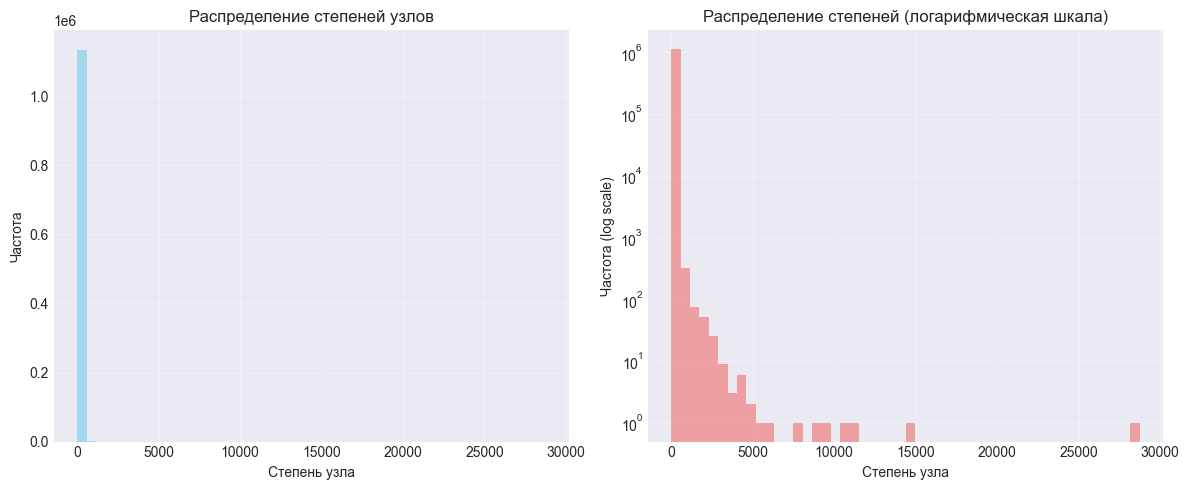

In [5]:
# Создание графа NetworkX
print("\nСоздание графа...")
G = nx.Graph()
G.add_edges_from(edges)

# Основные характеристики графа
print(f"Количество узлов: {G.number_of_nodes()}")
print(f"Количество ребер: {G.number_of_edges()}")
print(f"Средняя степень: {np.mean([d for n, d in G.degree()]):.2f}")
print(f"Плотность графа: {nx.density(G):.6f}")

# Распределение степеней узлов
degrees = [d for n, d in G.degree()]
degree_counts = Counter(degrees)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(degrees, bins=50, alpha=0.7, color='skyblue')
plt.xlabel('Степень узла')
plt.ylabel('Частота')
plt.title('Распределение степеней узлов')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(degrees, bins=50, alpha=0.7, color='lightcoral', log=True)
plt.xlabel('Степень узла')
plt.ylabel('Частота (log scale)')
plt.title('Распределение степеней (логарифмическая шкала)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Визуализация случайного подмножества графа...
Размер подграфа: 353 узлов, 262 ребер


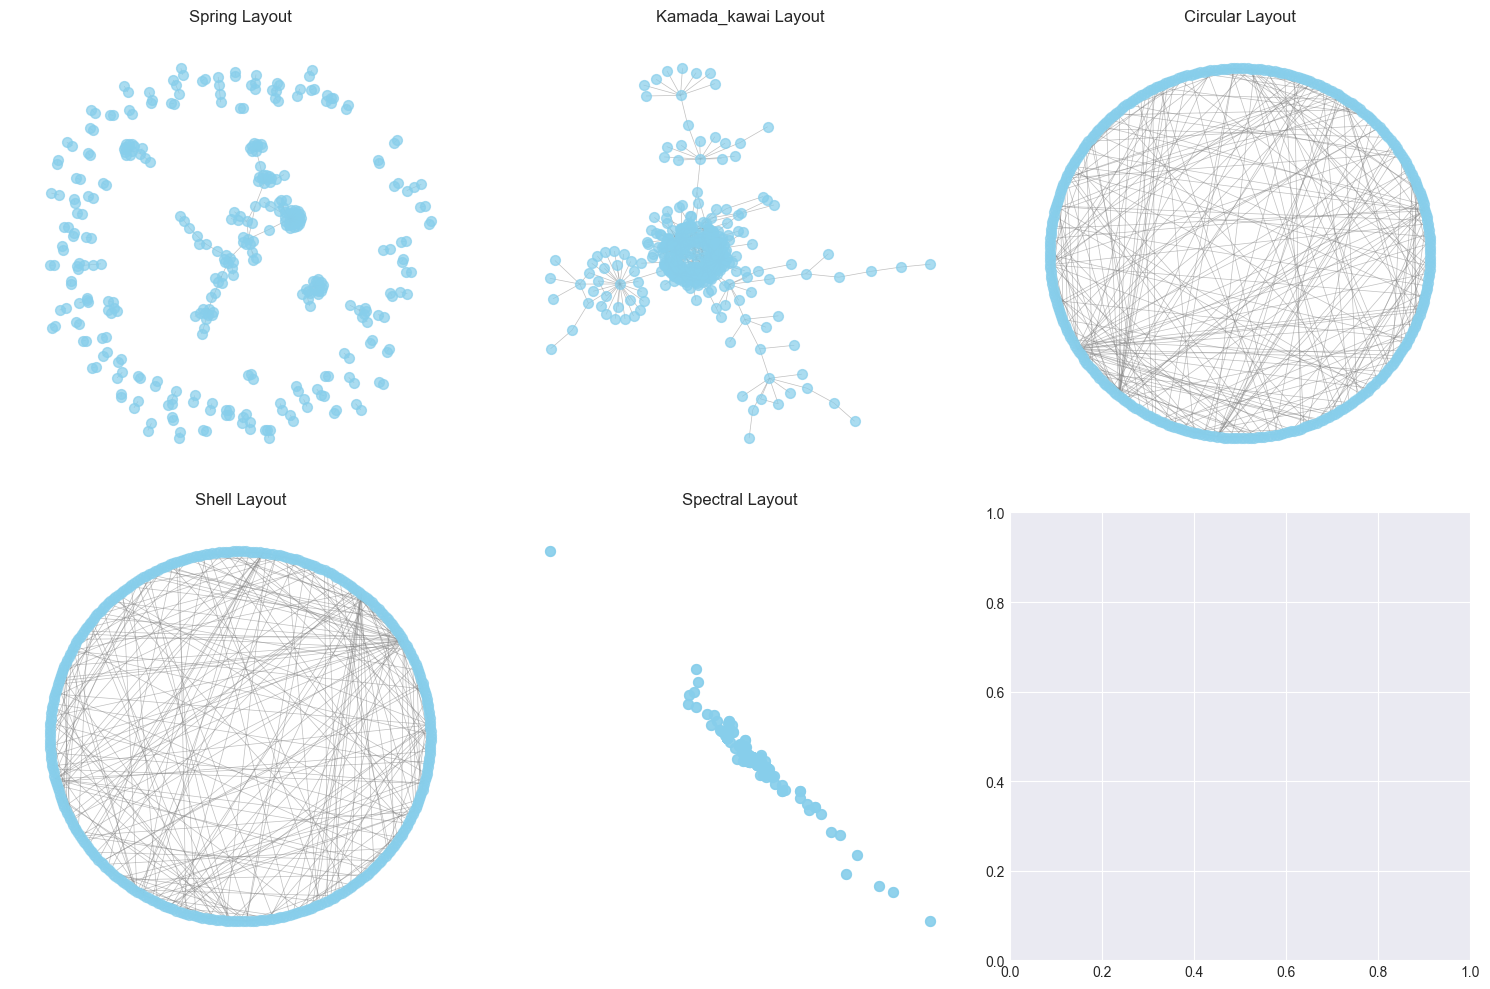

In [6]:
# Выбор случайного подмножества узлов для визуализации
print("\nВизуализация случайного подмножества графа...")
sample_size = 10000
all_nodes = list(G.nodes())

if len(all_nodes) > sample_size:
    sampled_nodes = random.sample(all_nodes, sample_size)
    subgraph = G.subgraph(sampled_nodes)
    
    # Убираем изолированные вершины для визуализации
    subgraph = subgraph.subgraph([n for n in subgraph.nodes() if subgraph.degree(n) > 0])
    
    print(f"Размер подграфа: {subgraph.number_of_nodes()} узлов, {subgraph.number_of_edges()} ребер")
    
    # Попробуем разные layout алгоритмы
    layout_methods = {
        'spring': nx.spring_layout,
        'kamada_kawai': nx.kamada_kawai_layout,
        'circular': nx.circular_layout,
        'shell': nx.shell_layout,
        'spectral': nx.spectral_layout
    }
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, (name, layout_func) in enumerate(list(layout_methods.items())[:6]):
        if idx >= len(axes):
            break
            
        try:
            pos = layout_func(subgraph)
            nx.draw_networkx_nodes(subgraph, pos, ax=axes[idx], 
                                  node_size=50, node_color='skyblue', alpha=0.7)
            nx.draw_networkx_edges(subgraph, pos, ax=axes[idx], 
                                  width=0.5, alpha=0.5, edge_color='gray')
            axes[idx].set_title(f'{name.capitalize()} Layout')
            axes[idx].axis('off')
        except Exception as e:
            print(f"Ошибка при отрисовке {name}: {e}")
            axes[idx].set_title(f'{name} - Ошибка')
            axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("Граф слишком мал для выборки")


Запуск алгоритма Label Propagation...
Алгоритм завершился за 50 итераций
Найдено 41635 сообществ
Средний размер сообщества: 27.26
Максимальный размер: 270217
Минимальный размер: 1


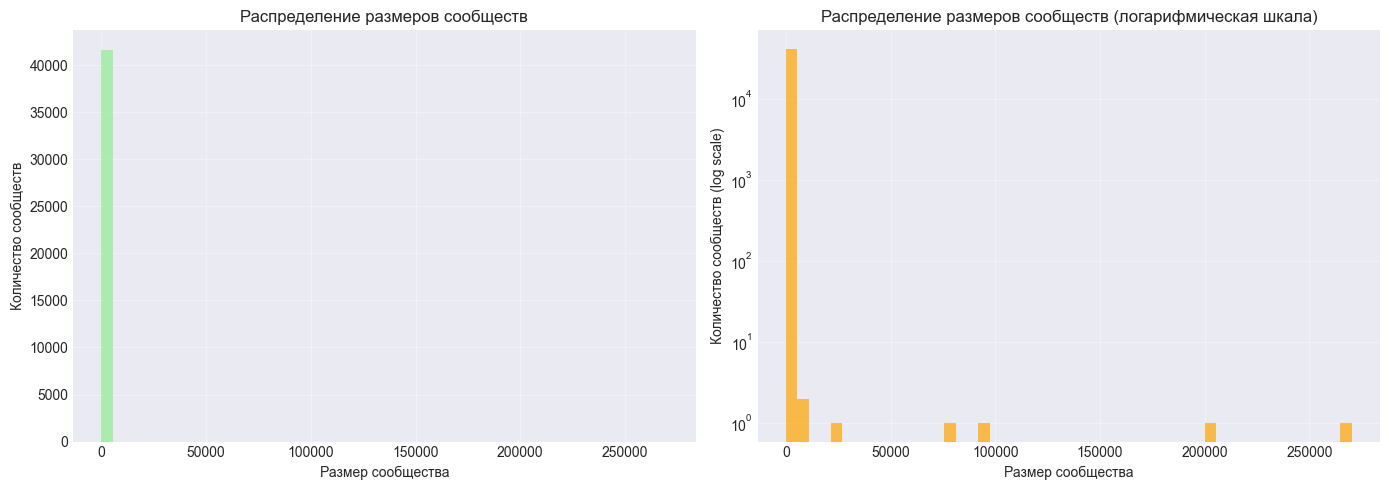

In [7]:
class LabelPropagation:
    """Реализация алгоритма распространения меток (LPA)"""
    
    def __init__(self, max_iterations=100, tolerance=1e-6, random_state=42):
        self.max_iterations = max_iterations
        self.tolerance = tolerance
        self.random_state = random_state
        self.communities = None
        self.n_iterations = 0
        
    def fit(self, graph):
        """Выполнение алгоритма LPA на графе"""
        random.seed(self.random_state)
        
        # Инициализация: каждой ноде своя метка
        labels = {node: i for i, node in enumerate(graph.nodes())}
        nodes = list(graph.nodes())
        
        # Основной цикл алгоритма
        for iteration in range(self.max_iterations):
            changed = False
            random.shuffle(nodes)
            
            for node in nodes:
                # Собираем метки соседей
                neighbor_labels = [labels[neighbor] for neighbor in graph.neighbors(node)]
                if not neighbor_labels:
                    continue
                    
                # Находим наиболее частую метку
                label_counts = Counter(neighbor_labels)
                max_count = max(label_counts.values())
                most_common_labels = [label for label, count in label_counts.items() 
                                     if count == max_count]
                
                # Выбираем случайную метку из наиболее частых
                current_label = labels[node]
                new_label = random.choice(most_common_labels)
                
                if current_label != new_label:
                    labels[node] = new_label
                    changed = True
            
            # Проверка сходимости
            if not changed:
                self.n_iterations = iteration + 1
                break
                
            if iteration == self.max_iterations - 1:
                self.n_iterations = self.max_iterations
        
        # Группировка узлов по меткам
        communities_dict = defaultdict(list)
        for node, label in labels.items():
            communities_dict[label].append(node)
        
        # Преобразуем в список сообществ
        self.communities = list(communities_dict.values())
        
        return self
    
    def get_communities(self):
        """Возвращает найденные сообщества"""
        return self.communities
    
    def get_community_sizes(self):
        """Возвращает размеры сообществ"""
        return [len(comm) for comm in self.communities]

# Запуск алгоритма LPA
print("\nЗапуск алгоритма Label Propagation...")
lpa = LabelPropagation(max_iterations=50, random_state=42)
lpa.fit(G)

communities = lpa.get_communities()
community_sizes = lpa.get_community_sizes()

print(f"Алгоритм завершился за {lpa.n_iterations} итераций")
print(f"Найдено {len(communities)} сообществ")
print(f"Средний размер сообщества: {np.mean(community_sizes):.2f}")
print(f"Максимальный размер: {max(community_sizes)}")
print(f"Минимальный размер: {min(community_sizes)}")

# Распределение размеров сообществ
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(community_sizes, bins=50, alpha=0.7, color='lightgreen')
plt.xlabel('Размер сообщества')
plt.ylabel('Количество сообществ')
plt.title('Распределение размеров сообществ')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(community_sizes, bins=50, alpha=0.7, color='orange', log=True)
plt.xlabel('Размер сообщества')
plt.ylabel('Количество сообществ (log scale)')
plt.title('Распределение размеров сообществ (логарифмическая шкала)')
plt.yscale('log')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Топ-10 самых больших сообществ:
1. Размер: 270217 узлов
2. Размер: 205279 узлов
3. Размер: 96208 узлов
4. Размер: 80268 узлов
5. Размер: 25761 узлов
6. Размер: 10535 узлов
7. Размер: 5490 узлов
8. Размер: 4876 узлов
9. Размер: 2700 узлов
10. Размер: 2382 узлов


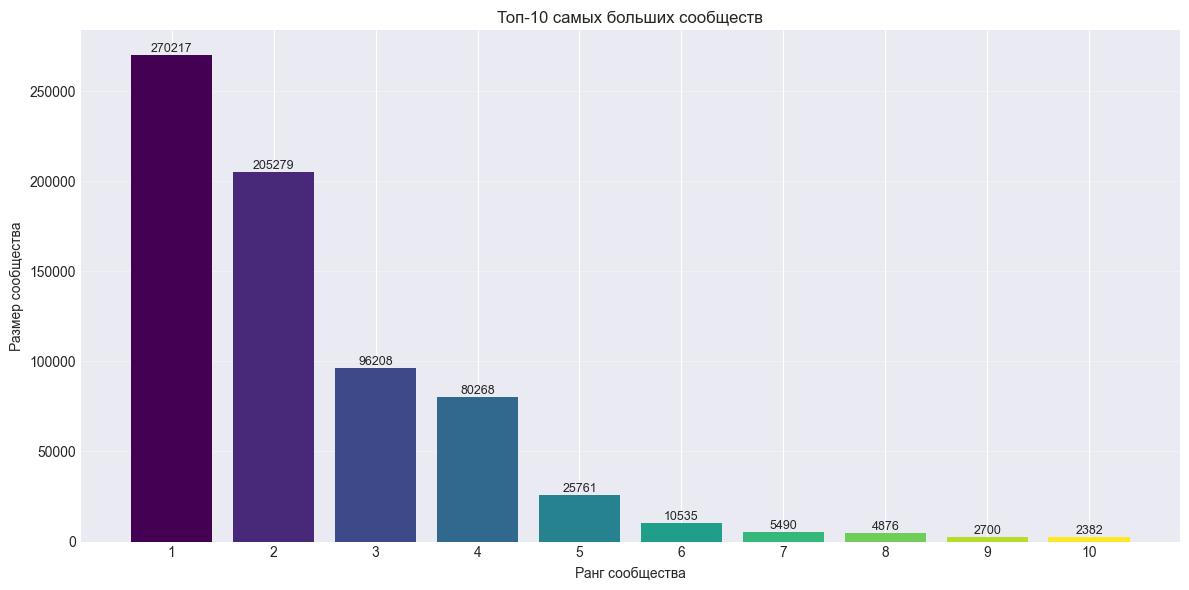

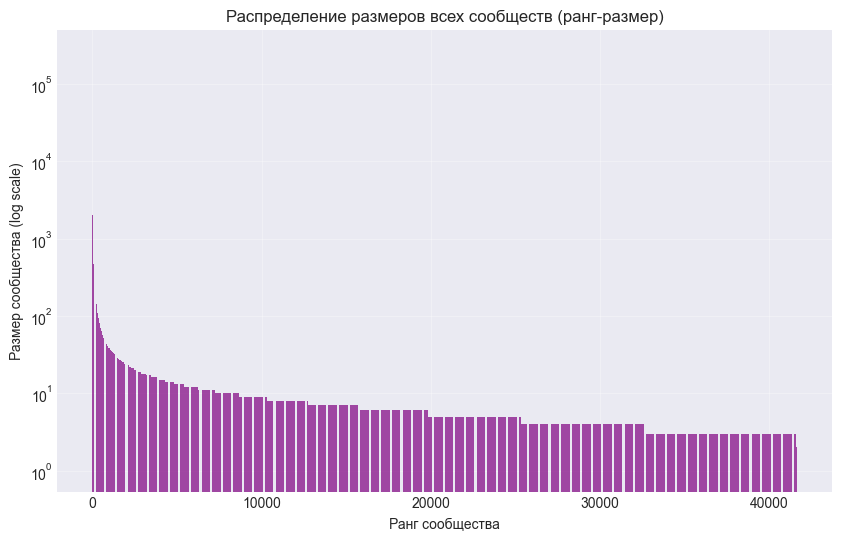

In [8]:
# Находим топ-10 самых больших сообществ
sorted_communities = sorted(communities, key=len, reverse=True)
top_10_communities = sorted_communities[:10]
top_10_sizes = [len(comm) for comm in top_10_communities]

print("\nТоп-10 самых больших сообществ:")
for i, (comm, size) in enumerate(zip(top_10_communities, top_10_sizes), 1):
    print(f"{i}. Размер: {size} узлов")

# Визуализация размеров топ-10 сообществ
plt.figure(figsize=(12, 6))
bars = plt.bar(range(1, 11), top_10_sizes, color=plt.cm.viridis(np.linspace(0, 1, 10)))
plt.xlabel('Ранг сообщества')
plt.ylabel('Размер сообщества')
plt.title('Топ-10 самых больших сообществ')
plt.xticks(range(1, 11))
plt.grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for bar, size in zip(bars, top_10_sizes):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{size}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Логарифмическая шкала для всех сообществ
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(community_sizes) + 1), sorted(community_sizes, reverse=True), 
        alpha=0.7, color='purple')
plt.xlabel('Ранг сообщества')
plt.ylabel('Размер сообщества (log scale)')
plt.title('Распределение размеров всех сообществ (ранг-размер)')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()


Визуализация топ-10 сообществ...
Сообщество 7 слишком большое для визуализации (5490 узлов)
Сообщество 6 слишком большое для визуализации (10535 узлов)
Сообщество 5 слишком большое для визуализации (25761 узлов)
Сообщество 4 слишком большое для визуализации (80268 узлов)
Сообщество 3 слишком большое для визуализации (96208 узлов)
Сообщество 2 слишком большое для визуализации (205279 узлов)
Сообщество 1 слишком большое для визуализации (270217 узлов)


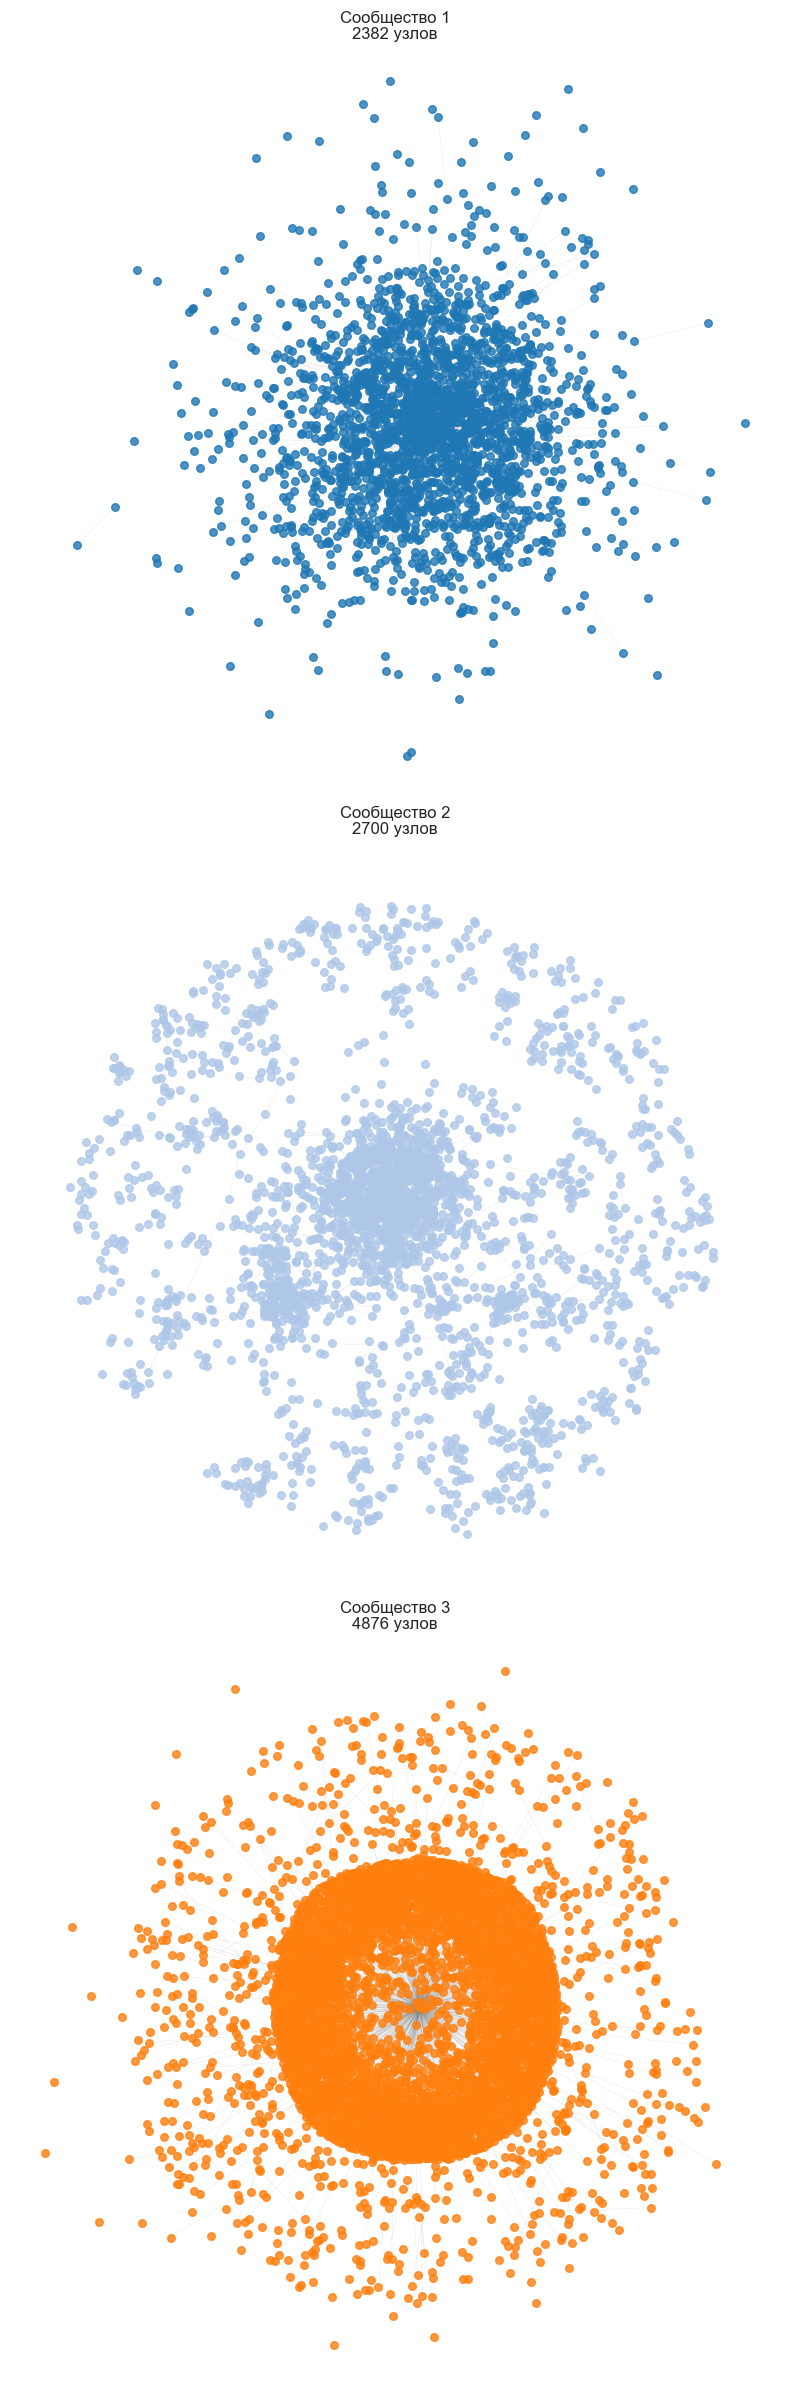

In [ ]:
# Визуализация каждого из топ-10 сообществ
print("\nВизуализация топ-10 сообществ...")

fig, axes = plt.subplots(3, 1, figsize=(8, 24))
axes = axes.flatten()

for idx, community in enumerate(top_10_communities[::-1]):
    # Создаем подграф для сообщества
    subgraph = G.subgraph(community)
    
    # Пропускаем слишком большие для визуализации
    if subgraph.number_of_nodes() > 5000:
        print(f"Сообщество {10 -idx} слишком большое для визуализации ({len(community)} узлов)")
        continue
    
    try:
        pos = nx.spring_layout(subgraph)
        
        # Рисуем граф
        nx.draw_networkx_nodes(subgraph, pos, ax=axes[idx], 
                              node_size=30, 
                              node_color=plt.cm.tab20(idx % 20),
                              alpha=0.8)
        
        # Рисуем только часть ребер для лучшей читаемости
        edges = list(subgraph.edges())
        if len(edges) > 1000:
            edges = random.sample(edges, 1000)
        
        nx.draw_networkx_edges(subgraph, pos, ax=axes[idx], 
                              edgelist=edges,
                              width=0.3, alpha=0.2, edge_color='gray')
        
        axes[idx].set_title(f'Сообщество {idx+1}\n{len(community)} узлов')
        axes[idx].axis('off')
        
    except Exception as e:
        print(f"Ошибка при визуализации сообщества {10-idx}: {e}")
        axes[idx].set_title(f'Сообщество {idx+1}\nОшибка визуализации')
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [47]:
# Вычисление метрик качества кластеризации
print("\nВычисление метрик качества кластеризации...")

from sklearn.metrics import pairwise_distances
import scipy.sparse as sp

# Для экономии вычислений возьмем только 100000 случайных узлов
sample_nodes = random.sample(list(G.nodes()), 100000)
G_sample = G.subgraph(sample_nodes)

# Матрица смежности для вычисления метрик
adj_matrix = nx.to_numpy_array(G_sample)

# Модулярность (используем встроенную функцию NetworkX для нашего LPA)
lpa_sample = LabelPropagation(max_iterations=50, random_state=42)
lpa_sample.fit(G_sample)

# Преобразуем сообщества в формат для вычисления модулярности
partition = {}
for i, community in enumerate(lpa_sample.get_communities()):
    for node in community:
        partition[node] = i

modularity = nx.algorithms.community.quality.modularity(G_sample, 
                                                         [set(comm) for comm in lpa_sample.get_communities()])
print(f"Модулярность кластеризации: {modularity:.4f}")

# Коэффициент кластеризации для сообществ
print("\nКоэффициент кластеризации для топ-5 сообществ:")
for i, community in enumerate(top_10_communities[:5], 1):
    if len(community) >= 3:  # Нужно хотя бы 3 узла для коэффициента кластеризации
        subgraph = G.subgraph(community)
        try:
            avg_clustering = nx.average_clustering(subgraph)
            print(f"Сообщество {i} ({len(community)} узлов): коэффициент кластеризации = {avg_clustering:.4f}")
        except:
            print(f"Сообщество {i}: не удалось вычислить коэффициент кластеризации")


Вычисление метрик качества кластеризации...


: 

In [1]:
# Финальная визуализация и вывод результатов
print("\n" + "="*60)
print("СВОДКА РЕЗУЛЬТАТОВ")
print("="*60)

print(f"\nИсходный граф:")
print(f"  • Узлов: {G.number_of_nodes()}")
print(f"  • Рёбер: {G.number_of_edges()}")
print(f"  • Средняя степень: {np.mean([d for n, d in G.degree()]):.2f}")

print(f"\nРезультаты LPA (основной запуск):")
print(f"  • Найдено сообществ: {len(communities)}")
print(f"  • Итераций выполнено: {lpa.n_iterations}")
print(f"  • Размер самого большого сообщества: {max(community_sizes)}")
print(f"  • Размер самого маленького сообщества: {min(community_sizes)}")
print(f"  • Медианный размер сообщества: {np.median(community_sizes):.1f}")
print(f"  • 99.9 перцентиль размера сообщества: {np.quantile(community_sizes, 0.999):.1f}")

print(f"\nТоп-5 сообществ по размеру:")
for i, size in enumerate(top_10_sizes[:5], 1):
    percentage = (size / G.number_of_nodes()) * 100
    print(f"  {i}. {size} узлов ({percentage:.2f}% от общего числа)")

# Финальная визуализация: распределение размеров в логарифмических шкалах
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sorted_sizes = sorted(community_sizes, reverse=True)
plt.plot(range(1, len(sorted_sizes) + 1), sorted_sizes, 'b-', alpha=0.7, linewidth=2)
plt.xlabel('Ранг сообщества (log scale)')
plt.ylabel('Размер сообщества (log scale)')
plt.title('Ранг-размер распределение')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
n, bins, patches = plt.hist(community_sizes, bins=50, alpha=0.7, color='green')
plt.xlabel('Размер сообщества (log scale)')
plt.ylabel('Количество сообществ (log scale)')
plt.title('Распределение размеров сообществ')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


СВОДКА РЕЗУЛЬТАТОВ

Исходный граф:


NameError: name 'G' is not defined


АНАЛИЗ ВНУТРЕННЕЙ СТРУКТУРЫ 8, 9 и 10 СООБЩЕСТВ

Сообщество 1 (2382 узлов):
  • Рёбер: 6922
  • Плотность: 0.002441
  • Средняя степень: 5.81
  • Средний коэффициент кластеризации: 0.1483
  • Максимальная степень: 414

Сообщество 2 (2700 узлов):
  • Рёбер: 3638
  • Плотность: 0.000998
  • Средняя степень: 2.69
  • Средний коэффициент кластеризации: 0.0728
  • Максимальная степень: 133

Сообщество 3 (4876 узлов):
  • Рёбер: 4911
  • Плотность: 0.000413
  • Средняя степень: 2.01
  • Средний коэффициент кластеризации: 0.0080
  • Максимальная степень: 4029


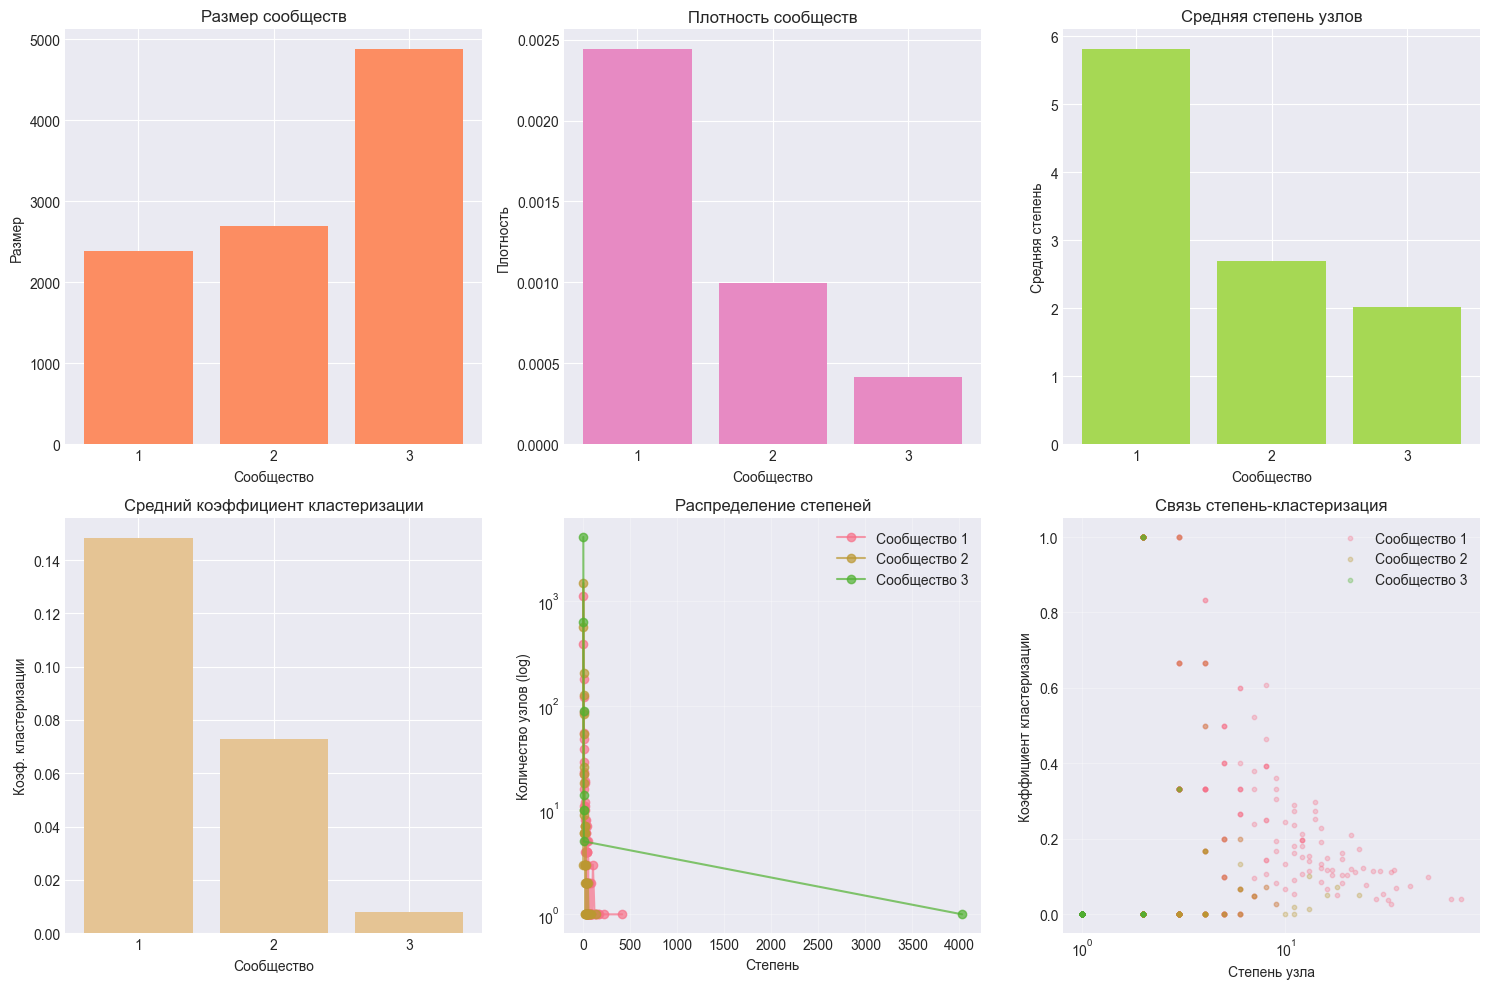

In [19]:
print("\n" + "="*60)
print("АНАЛИЗ ВНУТРЕННЕЙ СТРУКТУРЫ 8, 9 и 10 СООБЩЕСТВ")
print("="*60)

top_3_communities = top_10_communities[::-1][:3]

# Анализируем каждое сообщество отдельно
community_stats = []

for i, community in enumerate(top_3_communities, 1):
    subgraph = G.subgraph(community)
    
    # Основные метрики
    density = nx.density(subgraph)
    avg_clustering = nx.average_clustering(subgraph)
    degrees = [d for n, d in subgraph.degree()]
    avg_degree = np.mean(degrees)
    
    community_stats.append({
        'Сообщество': i,
        'Размер': len(community),
        'Рёбра': subgraph.number_of_edges(),
        'Плотность': density,
        'Средняя степень': avg_degree,
        'Коэф. кластеризации': avg_clustering,
        'Макс. степень': max(degrees) if degrees else 0
    })
    
    print(f"\nСообщество {i} ({len(community)} узлов):")
    print(f"  • Рёбер: {subgraph.number_of_edges()}")
    print(f"  • Плотность: {density:.6f}")
    print(f"  • Средняя степень: {avg_degree:.2f}")
    print(f"  • Средний коэффициент кластеризации: {avg_clustering:.4f}")
    print(f"  • Максимальная степень: {max(degrees) if degrees else 0}")

# Визуализация метрик сообществ
stats_df = pd.DataFrame(community_stats)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Размер сообществ
axes[0, 0].bar(stats_df['Сообщество'], stats_df['Размер'], color=plt.cm.Set2(0.2))
axes[0, 0].set_xlabel('Сообщество')
axes[0, 0].set_ylabel('Размер')
axes[0, 0].set_title('Размер сообществ')
axes[0, 0].set_xticks([1, 2, 3])

# 2. Плотность
axes[0, 1].bar(stats_df['Сообщество'], stats_df['Плотность'], color=plt.cm.Set2(0.4))
axes[0, 1].set_xlabel('Сообщество')
axes[0, 1].set_ylabel('Плотность')
axes[0, 1].set_title('Плотность сообществ')
axes[0, 1].set_xticks([1, 2, 3])

# 3. Средняя степень
axes[0, 2].bar(stats_df['Сообщество'], stats_df['Средняя степень'], color=plt.cm.Set2(0.6))
axes[0, 2].set_xlabel('Сообщество')
axes[0, 2].set_ylabel('Средняя степень')
axes[0, 2].set_title('Средняя степень узлов')
axes[0, 2].set_xticks([1, 2, 3])

# 4. Коэффициент кластеризации
axes[1, 0].bar(stats_df['Сообщество'], stats_df['Коэф. кластеризации'], color=plt.cm.Set2(0.8))
axes[1, 0].set_xlabel('Сообщество')
axes[1, 0].set_ylabel('Коэф. кластеризации')
axes[1, 0].set_title('Средний коэффициент кластеризации')
axes[1, 0].set_xticks([1, 2, 3])

# 5. Распределение степеней в логарифмической шкале
for i, community in enumerate(top_3_communities, 1):
    subgraph = G.subgraph(community)
    degrees = [d for n, d in subgraph.degree()]
    degree_counts = Counter(degrees)
    
    x = sorted(degree_counts.keys())
    y = [degree_counts[d] for d in x]
    
    axes[1, 1].plot(x, y, 'o-', label=f'Сообщество {i}', alpha=0.7)
    
axes[1, 1].set_xlabel('Степень')
axes[1, 1].set_ylabel('Количество узлов (log)')
axes[1, 1].set_title('Распределение степеней')
axes[1, 1].set_yscale('log')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 6. Связь между степенью и коэффициентом кластеризации
for i, community in enumerate(top_3_communities, 1):
    subgraph = G.subgraph(community)
    
    # Берем случайную выборку для визуализации
    if len(community) > 1000:
        sampled_nodes = random.sample(list(community), 1000)
        subgraph_sample = G.subgraph(sampled_nodes)
    else:
        subgraph_sample = subgraph
    
    degrees = [subgraph_sample.degree(n) for n in subgraph_sample.nodes()]
    clustering = [nx.clustering(subgraph_sample, n) for n in subgraph_sample.nodes()]
    
    axes[1, 2].scatter(degrees, clustering, alpha=0.3, 
                      label=f'Сообщество {i}', s=10)

axes[1, 2].set_xlabel('Степень узла')
axes[1, 2].set_ylabel('Коэффициент кластеризации')
axes[1, 2].set_title('Связь степень-кластеризация')
axes[1, 2].set_xscale('log')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "="*60)
print("LINEAR THRESHOLD MODEL (LTM) ДЛЯ ПОИСКА ВЛИЯТЕЛЬНЫХ УЗЛОВ")
print("="*60)

class LinearThresholdModel:
    """
    Упрощенная реализация Linear Threshold Model для поиска влиятельных узлов
    """
    
    def __init__(self, graph, thresholds=None, random_state=42):
        self.graph = graph
        self.random_state = random_state
        self.thresholds = thresholds or self._generate_random_thresholds()
        random.seed(random_state)
        
    def _generate_random_thresholds(self):
        """Генерация случайных порогов для узлов (по умолчанию uniform [0,1])"""
        return {node: random.uniform(0.3, 0.7) for node in self.graph.nodes()}
    
    def simulate_diffusion(self, seed_nodes, max_iterations=100):
        """
        Симуляция распространения влияния из начальных узлов
        
        Args:
            seed_nodes: список начальных узлов
            max_iterations: максимальное число итераций
            
        Returns:
            activated_nodes: множество активированных узлов
            activation_history: история активации по итерациям
        """
        # Инициализация
        activated = set(seed_nodes)
        newly_activated = set(seed_nodes)
        activation_history = [set(seed_nodes)]
        
        # Основной цикл распространения
        for iteration in range(max_iterations):
            if not newly_activated:
                break
                
            current_newly_activated = set()
            
            # Проверяем всех неактивированных соседей активированных узлов
            for node in list(self.graph.nodes()):
                if node in activated:
                    continue
                    
                # Считаем долю активированных соседей
                neighbors = list(self.graph.neighbors(node))
                if not neighbors:
                    continue
                    
                activated_neighbors = [n for n in neighbors if n in activated]
                fraction_activated = len(activated_neighbors) / len(neighbors)
                
                # Проверяем превышение порога
                if fraction_activated >= self.thresholds[node]:
                    current_newly_activated.add(node)
            
            # Обновляем множества
            activated.update(current_newly_activated)
            newly_activated = current_newly_activated
            activation_history.append(set(current_newly_activated))
            
            if not newly_activated:
                break
        
        return activated, activation_history
    
    def find_influential_nodes(self, k=3, num_simulations=100):
        """
        Поиск k наиболее влиятельных узлов с помощью жадного алгоритма
        
        Args:
            k: количество влиятельных узлов для поиска
            num_simulations: количество симуляций для оценки влияния
            
        Returns:
            influential_nodes: список наиболее влиятельных узлов
            influence_scores: словарь с оценками влияния для всех узлов
        """
        nodes = list(self.graph.nodes())
        influence_scores = {node: 0 for node in nodes}
        
        # Жадный алгоритм для выбора k узлов
        selected_nodes = []
        remaining_nodes = set(nodes)
        
        for _ in range(k):
            best_node = None
            best_marginal_gain = -1
            
            # Оцениваем каждого кандидата
            for candidate in tqdm(remaining_nodes, desc=f"Выбор узла {len(selected_nodes)+1}/{k}", leave=False):
                # Симулируем распространение от текущего набора + кандидат
                current_seeds = selected_nodes + [candidate]
                activated, _ = self.simulate_diffusion(current_seeds)
                
                # Оцениваем прирост
                marginal_gain = len(activated)
                
                if marginal_gain > best_marginal_gain:
                    best_marginal_gain = marginal_gain
                    best_node = candidate
            
            # Добавляем лучший узел
            if best_node:
                selected_nodes.append(best_node)
                remaining_nodes.remove(best_node)
                influence_scores[best_node] = best_marginal_gain
        
        return selected_nodes, influence_scores
    
    def fast_degree_based_selection(self, k=3):
        """
        Быстрый метод выбора влиятельных узлов на основе степени (для больших графов)
        """
        # Выбираем узлы с наибольшей степенью
        degrees = [(node, self.graph.degree(node)) for node in self.graph.nodes()]
        degrees.sort(key=lambda x: x[1], reverse=True)
        
        influential_nodes = [node for node, _ in degrees[:k]]
        influence_scores = {node: deg for node, deg in degrees[:k]}
        
        return influential_nodes, influence_scores


LINEAR THRESHOLD MODEL (LTM) ДЛЯ ПОИСКА ВЛИЯТЕЛЬНЫХ УЗЛОВ


In [34]:
print("\nПоиск топ-3 влиятельных узлов в каждом сообществе...")

# Словарь для хранения результатов
influential_nodes_by_community = {}
influence_scores_by_community = {}

for i, community in enumerate(top_3_communities, 1):
    print(f"\nАнализ сообщества {i} ({len(community)} узлов)...")
    
    # Создаем подграф для сообщества
    subgraph = G.subgraph(community)
    
    # Для больших сообществ используем быстрый метод на основе степени
    if len(community) > 5000:
        print("  Используем быстрый метод (на основе степени)...")
        ltm = LinearThresholdModel(subgraph, random_state=42)
        influential_nodes, influence_scores = ltm.fast_degree_based_selection(k=3)
    else:
        print("  Используем полный LTM алгоритм...")
        ltm = LinearThresholdModel(subgraph, random_state=42)
        influential_nodes, influence_scores = ltm.find_influential_nodes(k=3, num_simulations=50)
    
    influential_nodes_by_community[i] = influential_nodes
    influence_scores_by_community[i] = influence_scores
    
    print(f"  Топ-3 влиятельных узлов в сообществе {i}:")
    for j, node in enumerate(influential_nodes, 1):
        score = influence_scores[node]
        degree = subgraph.degree(node)
        print(f"    {j}. Узел {node}: влияние ≈ {score}, степень = {degree}")
    
    # Симулируем распространение влияния от выбранных узлов
    print("  Симуляция распространения влияния...")
    ltm_full = LinearThresholdModel(subgraph, random_state=42)
    activated, activation_history = ltm_full.simulate_diffusion(influential_nodes)
    
    print(f"  Итог распространения: {len(activated)} активированных узлов "
          f"({len(activated)/len(community)*100:.1f}% сообщества)")
    print(f"  Потребовалось итераций: {len(activation_history)}")



Поиск топ-3 влиятельных узлов в каждом сообществе...

Анализ сообщества 1 (2382 узлов)...
  Используем полный LTM алгоритм...


  Топ-3 влиятельных узлов в сообществе 1:
    1. Узел 635: влияние ≈ 66, степень = 414
    2. Узел 30445: влияние ≈ 120, степень = 216
    3. Узел 29811: влияние ≈ 166, степень = 125
  Симуляция распространения влияния...
  Итог распространения: 166 активированных узлов (7.0% сообщества)
  Потребовалось итераций: 4

Анализ сообщества 2 (2700 узлов)...
  Используем полный LTM алгоритм...


  Топ-3 влиятельных узлов в сообществе 2:
    1. Узел 89586: влияние ≈ 38, степень = 133
    2. Узел 79779: влияние ≈ 67, степень = 79
    3. Узел 79696: влияние ≈ 92, степень = 67
  Симуляция распространения влияния...
  Итог распространения: 92 активированных узлов (3.4% сообщества)
  Потребовалось итераций: 4

Анализ сообщества 3 (4876 узлов)...
  Используем полный LTM алгоритм...


  Топ-3 влиятельных узлов в сообществе 3:
    1. Узел 482709: влияние ≈ 3917, степень = 4029
    2. Узел 292423: влияние ≈ 3925, степень = 5
    3. Узел 885157: влияние ≈ 3932, степень = 2
  Симуляция распространения влияния...
  Итог распространения: 3932 активированных узлов (80.6% сообщества)
  Потребовалось итераций: 6



СИМУЛЯЦИЯ РАСПРОСТРАНЕНИЯ ВЛИЯНИЯ ОТ ВЫБРАННЫХ УЗЛОВ

Демонстрация на сообществе 1 (2382 узлов)
Влиятельные узлы: [635, 30445, 29811]

Симуляция распространения влияния...

Результаты симуляции:
• Начальные узлы: [635, 30445, 29811]
• Всего активировано узлов: 166
• Процент охвата: 7.0%
• Итераций до насыщения: 4


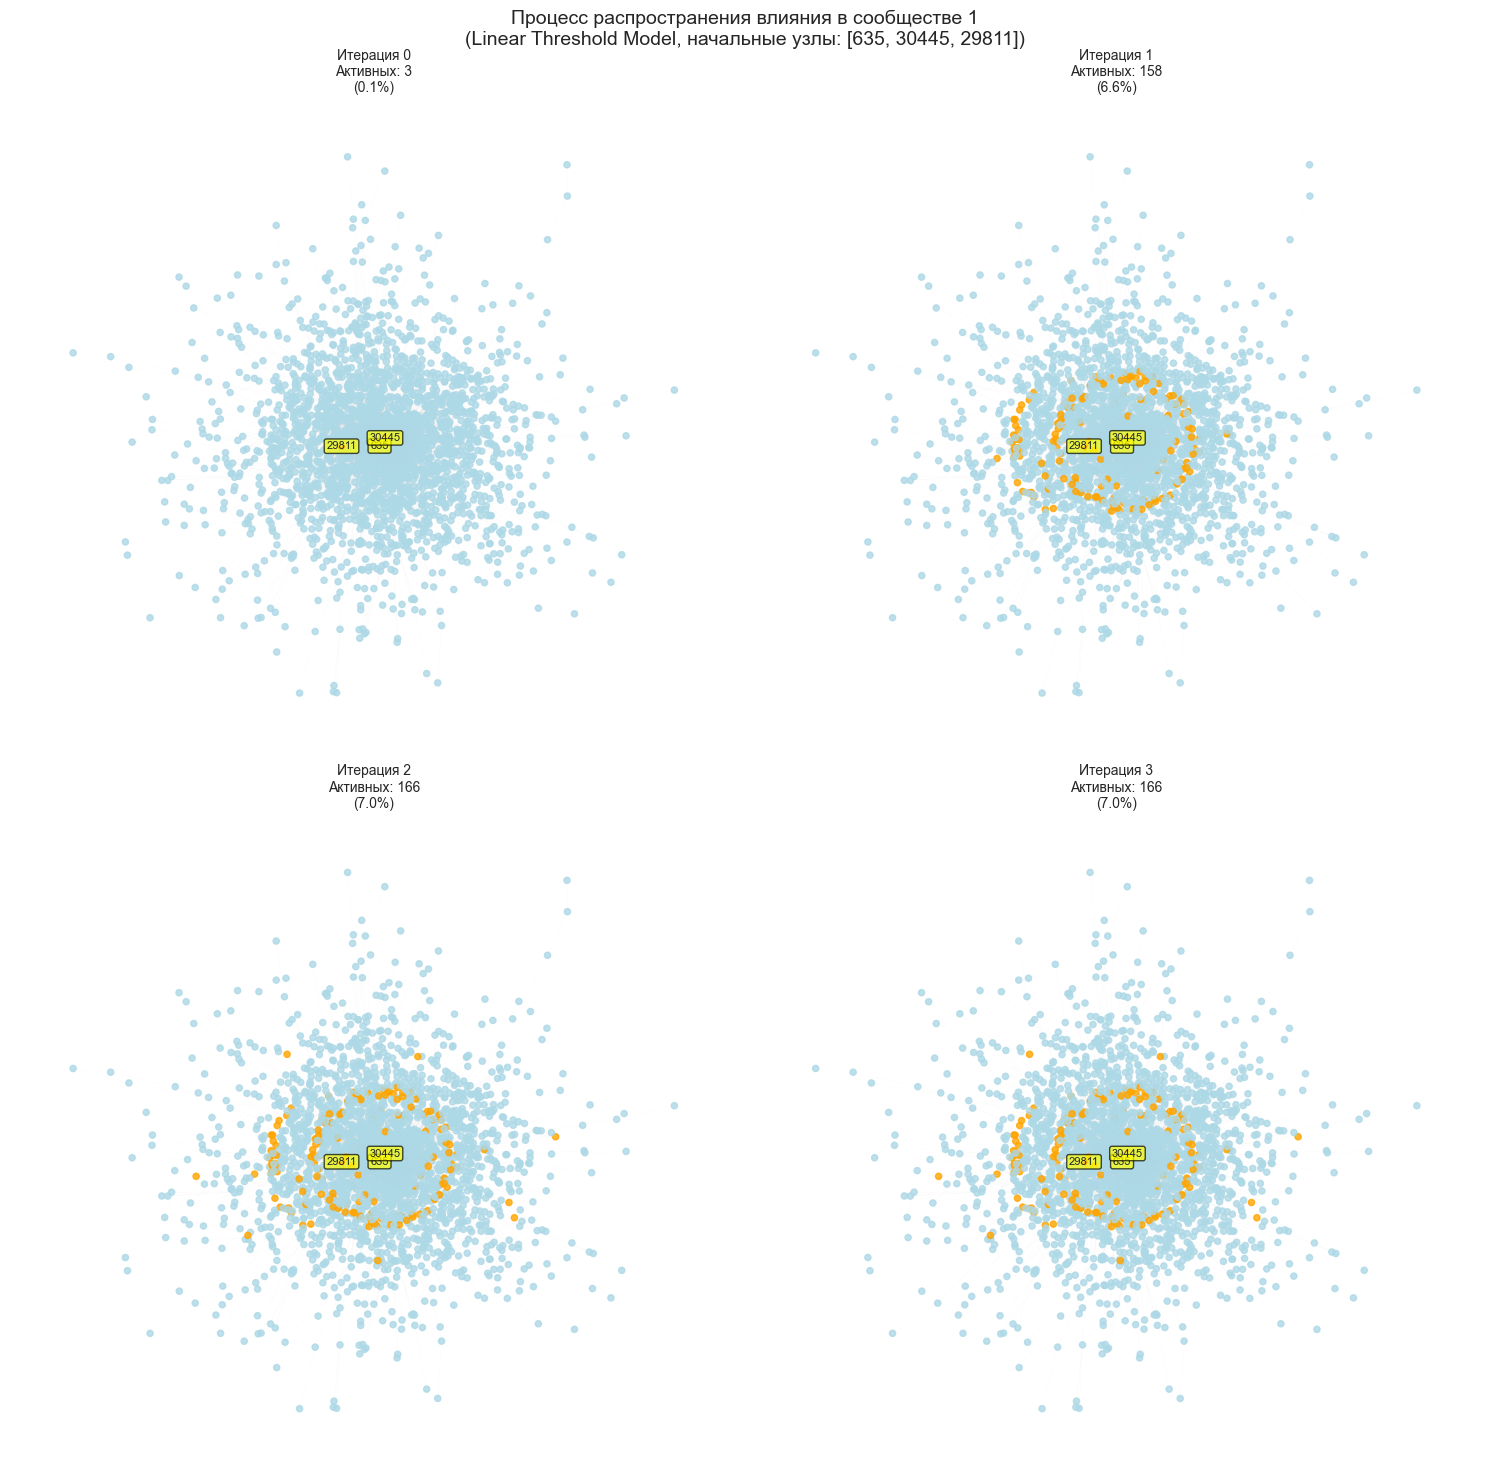

In [46]:
print("\n" + "="*60)
print("СИМУЛЯЦИЯ РАСПРОСТРАНЕНИЯ ВЛИЯНИЯ ОТ ВЫБРАННЫХ УЗЛОВ")
print("="*60)

# Выбираем одно сообщество для демонстрации
demo_community_idx = 1  # Первое сообщество
demo_community = top_3_communities[demo_community_idx-1]
demo_subgraph = G.subgraph(demo_community)
influential_nodes = influential_nodes_by_community[demo_community_idx]

print(f"\nДемонстрация на сообществе {demo_community_idx} ({len(demo_community)} узлов)")
print(f"Влиятельные узлы: {influential_nodes}")

# Создаем LTM модель для демонстрации
ltm_demo = LinearThresholdModel(demo_subgraph, random_state=42)

# Симулируем распространение
print("\nСимуляция распространения влияния...")
activated_nodes, activation_history = ltm_demo.simulate_diffusion(influential_nodes, max_iterations=20)

print(f"\nРезультаты симуляции:")
print(f"• Начальные узлы: {influential_nodes}")
print(f"• Всего активировано узлов: {len(activated_nodes)}")
print(f"• Процент охвата: {len(activated_nodes)/len(demo_community)*100:.1f}%")
print(f"• Итераций до насыщения: {len(activation_history)}")

# Визуализируем процесс распространения по итерациям
fig, axes = plt.subplots(2, 2, figsize=(15, 15))

# Выбираем ключевые итерации для визуализации
key_iterations = [0, 1, 2, 3, 5, len(activation_history)-1]
if len(key_iterations) > 6:
    key_iterations = [0, 1, 2, 3, 5, 10]

# Создаем layout для демонстрационного графа
pos = nx.spring_layout(demo_subgraph, seed=42, k=0.15)

for idx, iteration in enumerate(key_iterations):
    if iteration >= len(activation_history):
        break
        
    ax = axes[idx // 2, idx % 2]
    
    # Определяем какие узлы активны на этой итерации
    active_in_iteration = set()
    for i in range(iteration + 1):
        active_in_iteration.update(activation_history[i])
    
    # Цвета узлов: красный - начальные, оранжевый - активированные, синий - неактивные
    node_colors = []
    for node in demo_subgraph.nodes():
        if node in influential_nodes:
            node_colors.append('red')  # Начальные узлы
        elif node in active_in_iteration:
            node_colors.append('orange')  # Активированные
        else:
            node_colors.append('lightblue')  # Неактивные
    
    # Рисуем граф
    nx.draw_networkx_nodes(demo_subgraph, pos, ax=ax,
                          node_size=20,
                          node_color=node_colors,
                          alpha=0.8)
    
    nx.draw_networkx_edges(demo_subgraph, pos, ax=ax,
                          width=0.1,
                          alpha=0.1,
                          edge_color='gray')
    
    # Подписываем начальные узлы
    for node in influential_nodes:
        x, y = pos[node]
        ax.text(x, y, str(node), fontsize=8, ha='center', va='center',
               bbox=dict(boxstyle="round,pad=0.2", facecolor="yellow", alpha=0.7))
    
    ax.set_title(f'Итерация {iteration}\n'
                f'Активных: {len(active_in_iteration)}\n'
                f'({len(active_in_iteration)/len(demo_community)*100:.1f}%)',
                fontsize=10)
    ax.axis('off')

plt.suptitle(f'Процесс распространения влияния в сообществе {demo_community_idx}\n'
             f'(Linear Threshold Model, начальные узлы: {influential_nodes})',
             fontsize=14)
plt.tight_layout()
plt.show()


Сообщество 7 слишком большое для визуализации (5490 узлов)
Сообщество 6 слишком большое для визуализации (10535 узлов)
Сообщество 5 слишком большое для визуализации (25761 узлов)
Сообщество 4 слишком большое для визуализации (80268 узлов)
Сообщество 3 слишком большое для визуализации (96208 узлов)
Сообщество 2 слишком большое для визуализации (205279 узлов)
Сообщество 1 слишком большое для визуализации (270217 узлов)


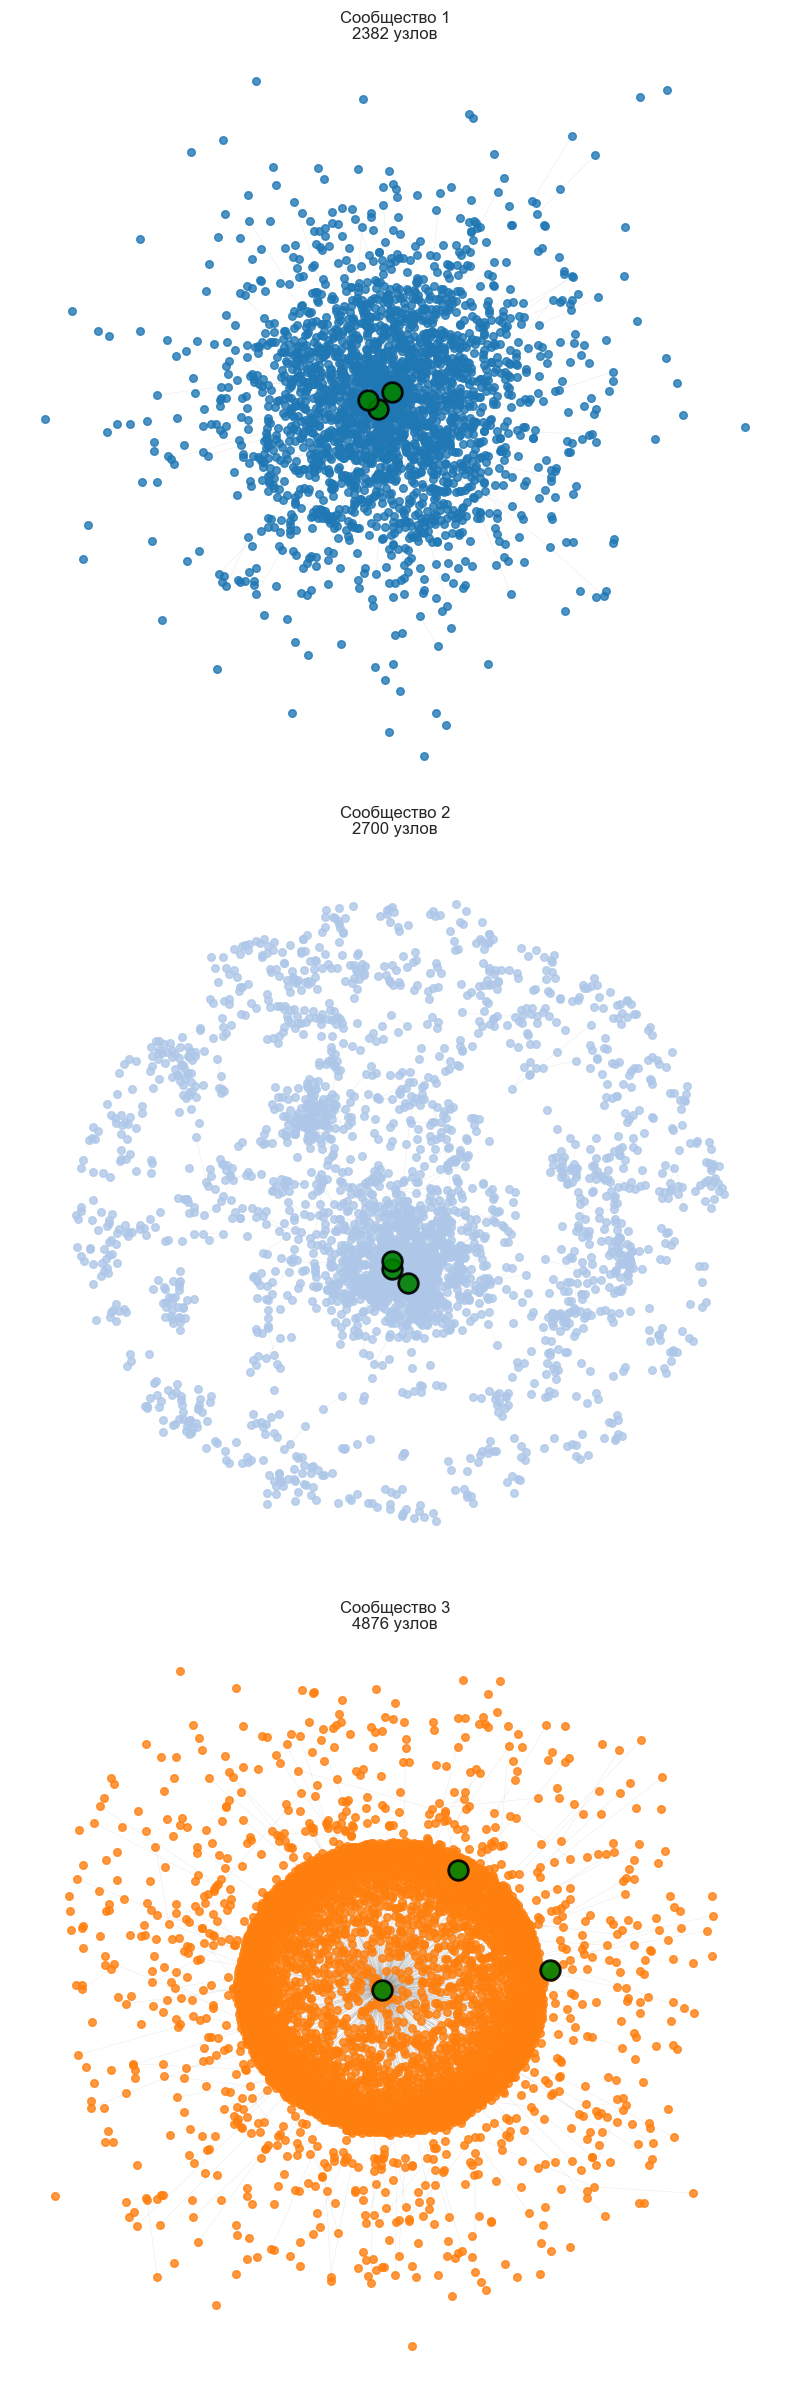

In [43]:
fig, axes = plt.subplots(3, 1, figsize=(8, 24))
axes = axes.flatten()

for idx, community in enumerate(top_10_communities[::-1]):
    # Создаем подграф для сообщества
    subgraph = G.subgraph(community)
    
    # Пропускаем слишком большие для визуализации
    if subgraph.number_of_nodes() > 5000:
        print(f"Сообщество {10 -idx} слишком большое для визуализации ({len(community)} узлов)")
        continue
    
    try:
        pos = nx.spring_layout(subgraph)
        
        # Рисуем граф
        nx.draw_networkx_nodes(subgraph, pos, ax=axes[idx], 
                              node_size=30, 
                              node_color=plt.cm.tab20(idx % 20),
                              alpha=0.8)
        
        # Рисуем только часть ребер для лучшей читаемости
        edges = list(subgraph.edges())
        if len(edges) > 1000:
            edges = random.sample(edges, 1000)
        
        nx.draw_networkx_edges(subgraph, pos, ax=axes[idx], 
                              edgelist=edges,
                              width=0.3, alpha=0.2, edge_color='gray')
        
        # Определяем влиятельные узлы для этого сообщества (если есть)
        community_number = idx + 1
        if community_number in influential_nodes_by_community:
            influential_nodes = influential_nodes_by_community[community_number]
            
            # Отфильтровываем узлы, которые действительно есть в текущем подграфе
            influential_nodes_in_subgraph = [node for node in influential_nodes 
                                            if node in subgraph.nodes()]
            
            if influential_nodes_in_subgraph:
                # Создаем подграф только из влиятельных узлов
                influential_subgraph = subgraph.subgraph(influential_nodes_in_subgraph)
                
                # Рисуем влиятельные узлы поверх обычных (красные, большего размера)
                nx.draw_networkx_nodes(influential_subgraph, pos, ax=axes[idx], 
                                      node_size=200, 
                                      node_color='green',
                                      alpha=0.9,
                                      edgecolors='black',
                                      linewidths=2)
        
        axes[idx].set_title(f'Сообщество {idx+1}\n{len(community)} узлов')
        axes[idx].axis('off')
        
    except Exception as e:
        print(f"Ошибка при визуализации сообщества {10-idx}: {e}")
        axes[idx].set_title(f'Сообщество {idx+1}\nОшибка визуализации')
        axes[idx].axis('off')

plt.tight_layout()
plt.show()